# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
from Tools.DatasetTools.Commoms import *
dataset = 'Fe-Mo'  # 'Cr-Co-W'#'Fe-Mo
target_case = 'EF_nmhcp'
components = dataset.split('-')
# sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

In [3]:
BS.shape

(292, 21)

# Population of phases

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


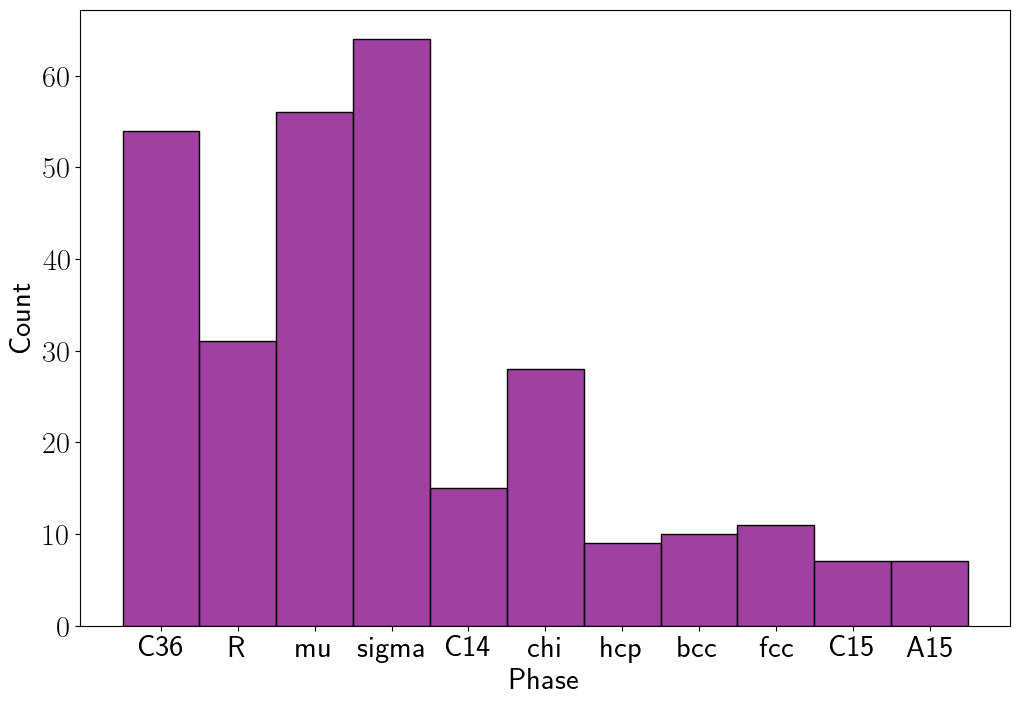

In [4]:
fig, ax = plt.subplots(figsize=(12,8))#, figsize=(12,8))
# sns.histplot(x = BS['Phase'], ax=ax)
#ax.hist(BS['Phase'])
ax = sns.histplot(x=BS['Phase'][BS['Phase']!='delta'], ax=ax, color='purple')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.eps')
fig.savefig(f'{dataset}/graphs/{dataset}_ClassCounts.pdf')

In [5]:
BS['Phase'].value_counts()

sigma    64
mu       56
C36      54
R        31
chi      28
C14      15
fcc      11
bcc      10
hcp       9
C15       7
A15       7
Name: Phase, dtype: int64

## Remove samples with very little representation

In [6]:
BS = BS[BS['Phase'] != 'delta']

# Extra features 

In [7]:
Features = Featurizer(BS)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


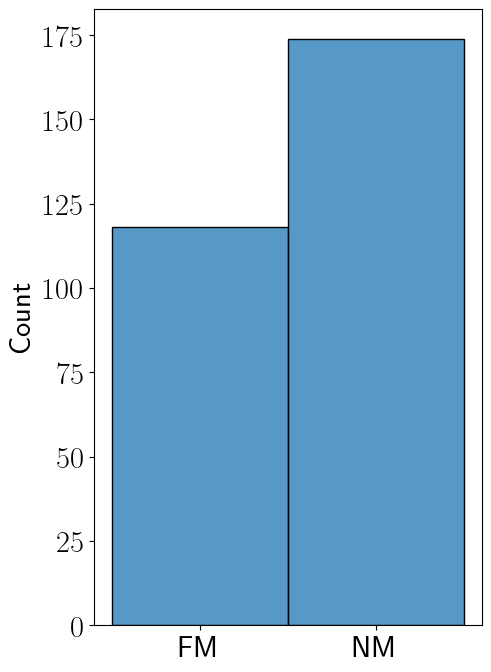

In [8]:
fig, ax = plt.subplots(figsize=(5,8))
sns.histplot(x = Features.Mag, ax=ax)
fig.savefig(f'{dataset}/graphs/{dataset}_FM_NM_counts.eps')

In [9]:
isfm = Features.Mag.str.contains('FM')

In [10]:
fmsamples = BS.index[isfm]

In [11]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [12]:
nmsamples = BS.index[~isfm]

## nm samples without fm counterpart:

In [13]:
nmsamples.difference(fmsamplesasnm)

Index(['Fe_pv10Mo_sv14.C36-ABBAB.NM', 'Fe_pv10Mo_sv14.C36-BABAB.NM',
       'Fe_pv10Mo_sv14.C36-BABBA.NM', 'Fe_pv11Mo_sv2.mu-AABAA.NM',
       'Fe_pv12.C14.NM', 'Fe_pv12Mo_sv12.C36-AAABB.NM',
       'Fe_pv12Mo_sv17.chi-BBAB.NM', 'Fe_pv14Mo_sv10.C36-AABAB.NM',
       'Fe_pv14Mo_sv10.C36-AABBA.NM', 'Fe_pv14Mo_sv10.C36-ABAAB.NM',
       'Fe_pv14Mo_sv10.C36-BAABA.NM', 'Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM',
       'Fe_pv16Mo_sv13.chi-BAAB.NM', 'Fe_pv17Mo_sv12.chi-AAAB.NM',
       'Fe_pv18Mo_sv6.C36-AAABA.NM', 'Fe_pv19Mo_sv34.R-ABAABABBBBB.NM',
       'Fe_pv1Mo_sv1.L10-NiAl-AB.NM', 'Fe_pv1Mo_sv3.D03-AB3.NM',
       'Fe_pv1Mo_sv52.R-ABBBBBBBBBB.NM', 'Fe_pv21Mo_sv32.R-AAAAABBBBBB.NM',
       'Fe_pv21Mo_sv32.R-AAABAABBBBB.NM', 'Fe_pv23Mo_sv30.R-AABABABABAB.NM',
       'Fe_pv24Mo_sv29.R-BBAAAABBBBB.NM', 'Fe_pv24Mo_sv6.sigma-BBAAA.NM',
       'Fe_pv27Mo_sv26.R-AAAAAABBBBB.NM', 'Fe_pv27Mo_sv26.R-AAAAABBABBB.NM',
       'Fe_pv27Mo_sv26.R-AAAABABABBB.NM', 'Fe_pv28Mo_sv1.chi-BAAA.NM',
       'Fe_pv29Mo_s

## fm samples as without nm counterpart:

In [14]:
fmsamplesasnm.difference(nmsamples)

Index(['Fe_pv1.fcc.NM', 'Fe_pv2.bcc-cubic.NM', 'Fe_pv30.sigma_Fe_pv.NM'], dtype='object')

# Distribution of Target Variables 

## total energy

In [15]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

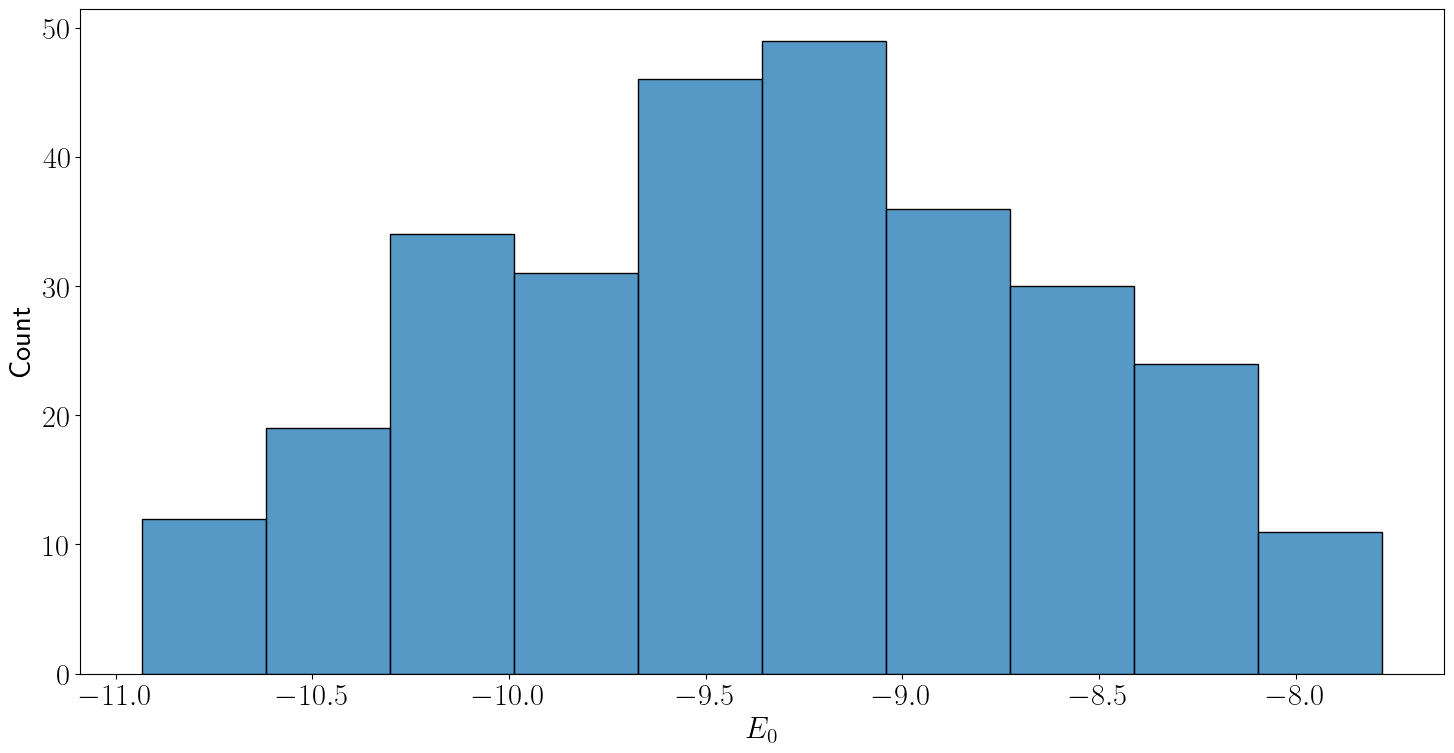

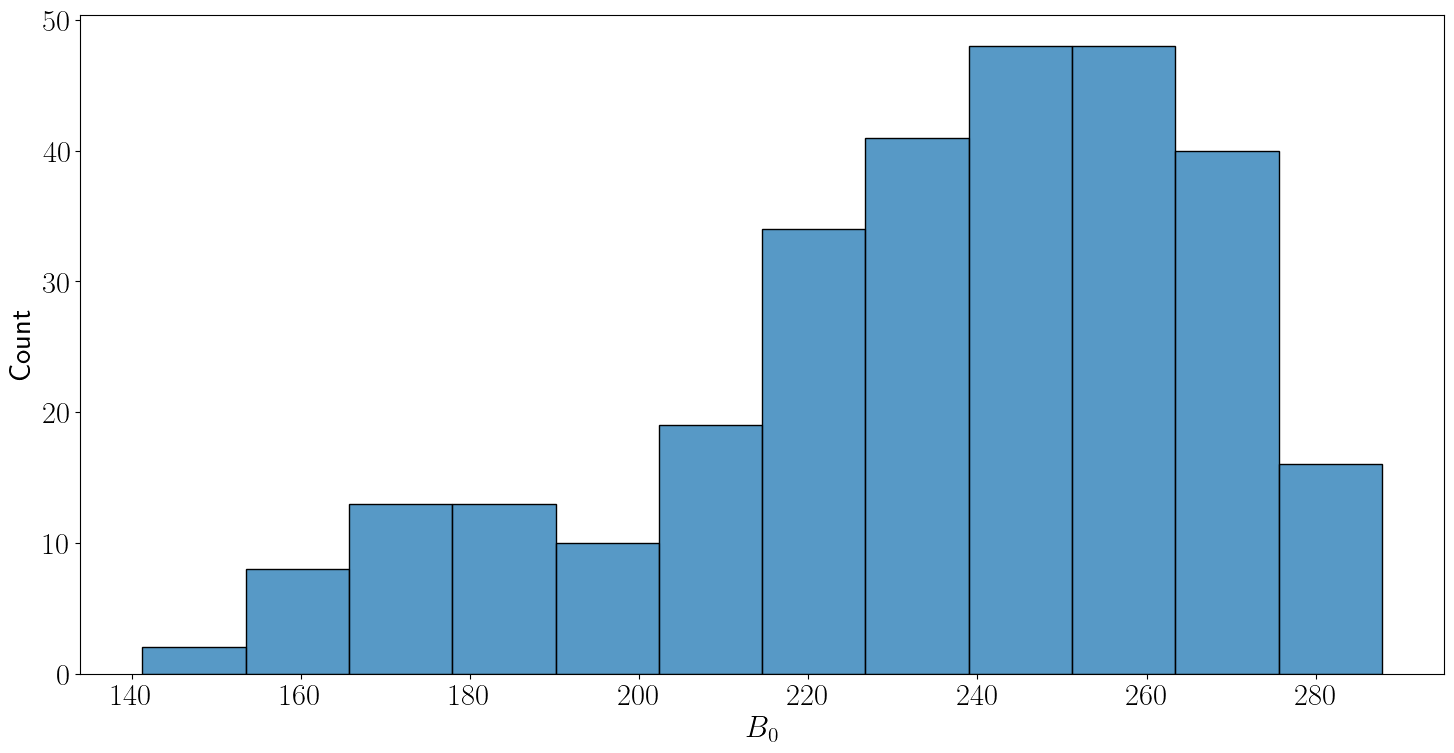

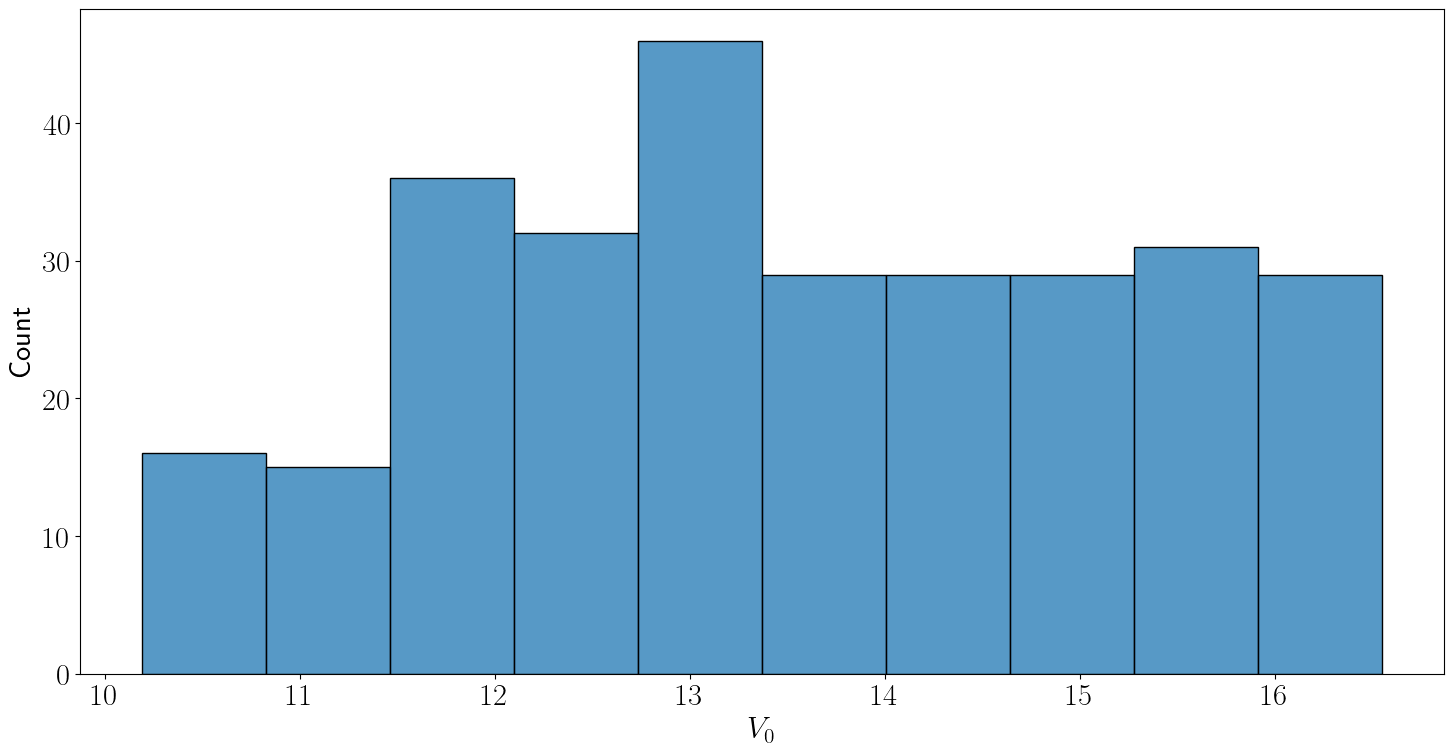

In [16]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [17]:
BS.sort_values(by='B0', inplace=True)

In [18]:
targets['E0'] = '$E_0$'

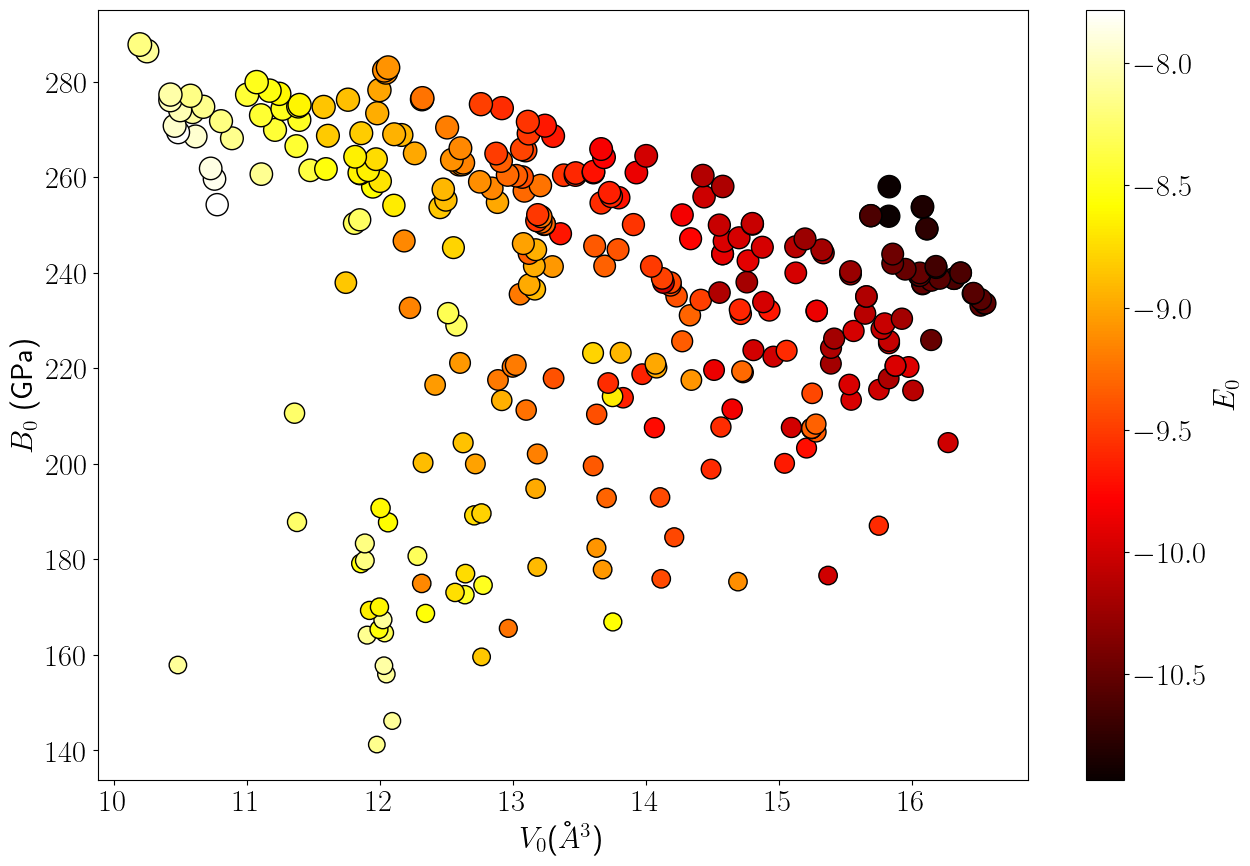

In [19]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.B0, c=BS['E0'], marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['B0']+' (GPa)')
plt.xlabel(targets['V0']+'($\\AA^3$)')
cbar.set_label(targets['E0'])

# Pair Plots

In [20]:
ToPlot = BS[list(targets.keys())]
ToPlot.columns = list(targets.values()) 

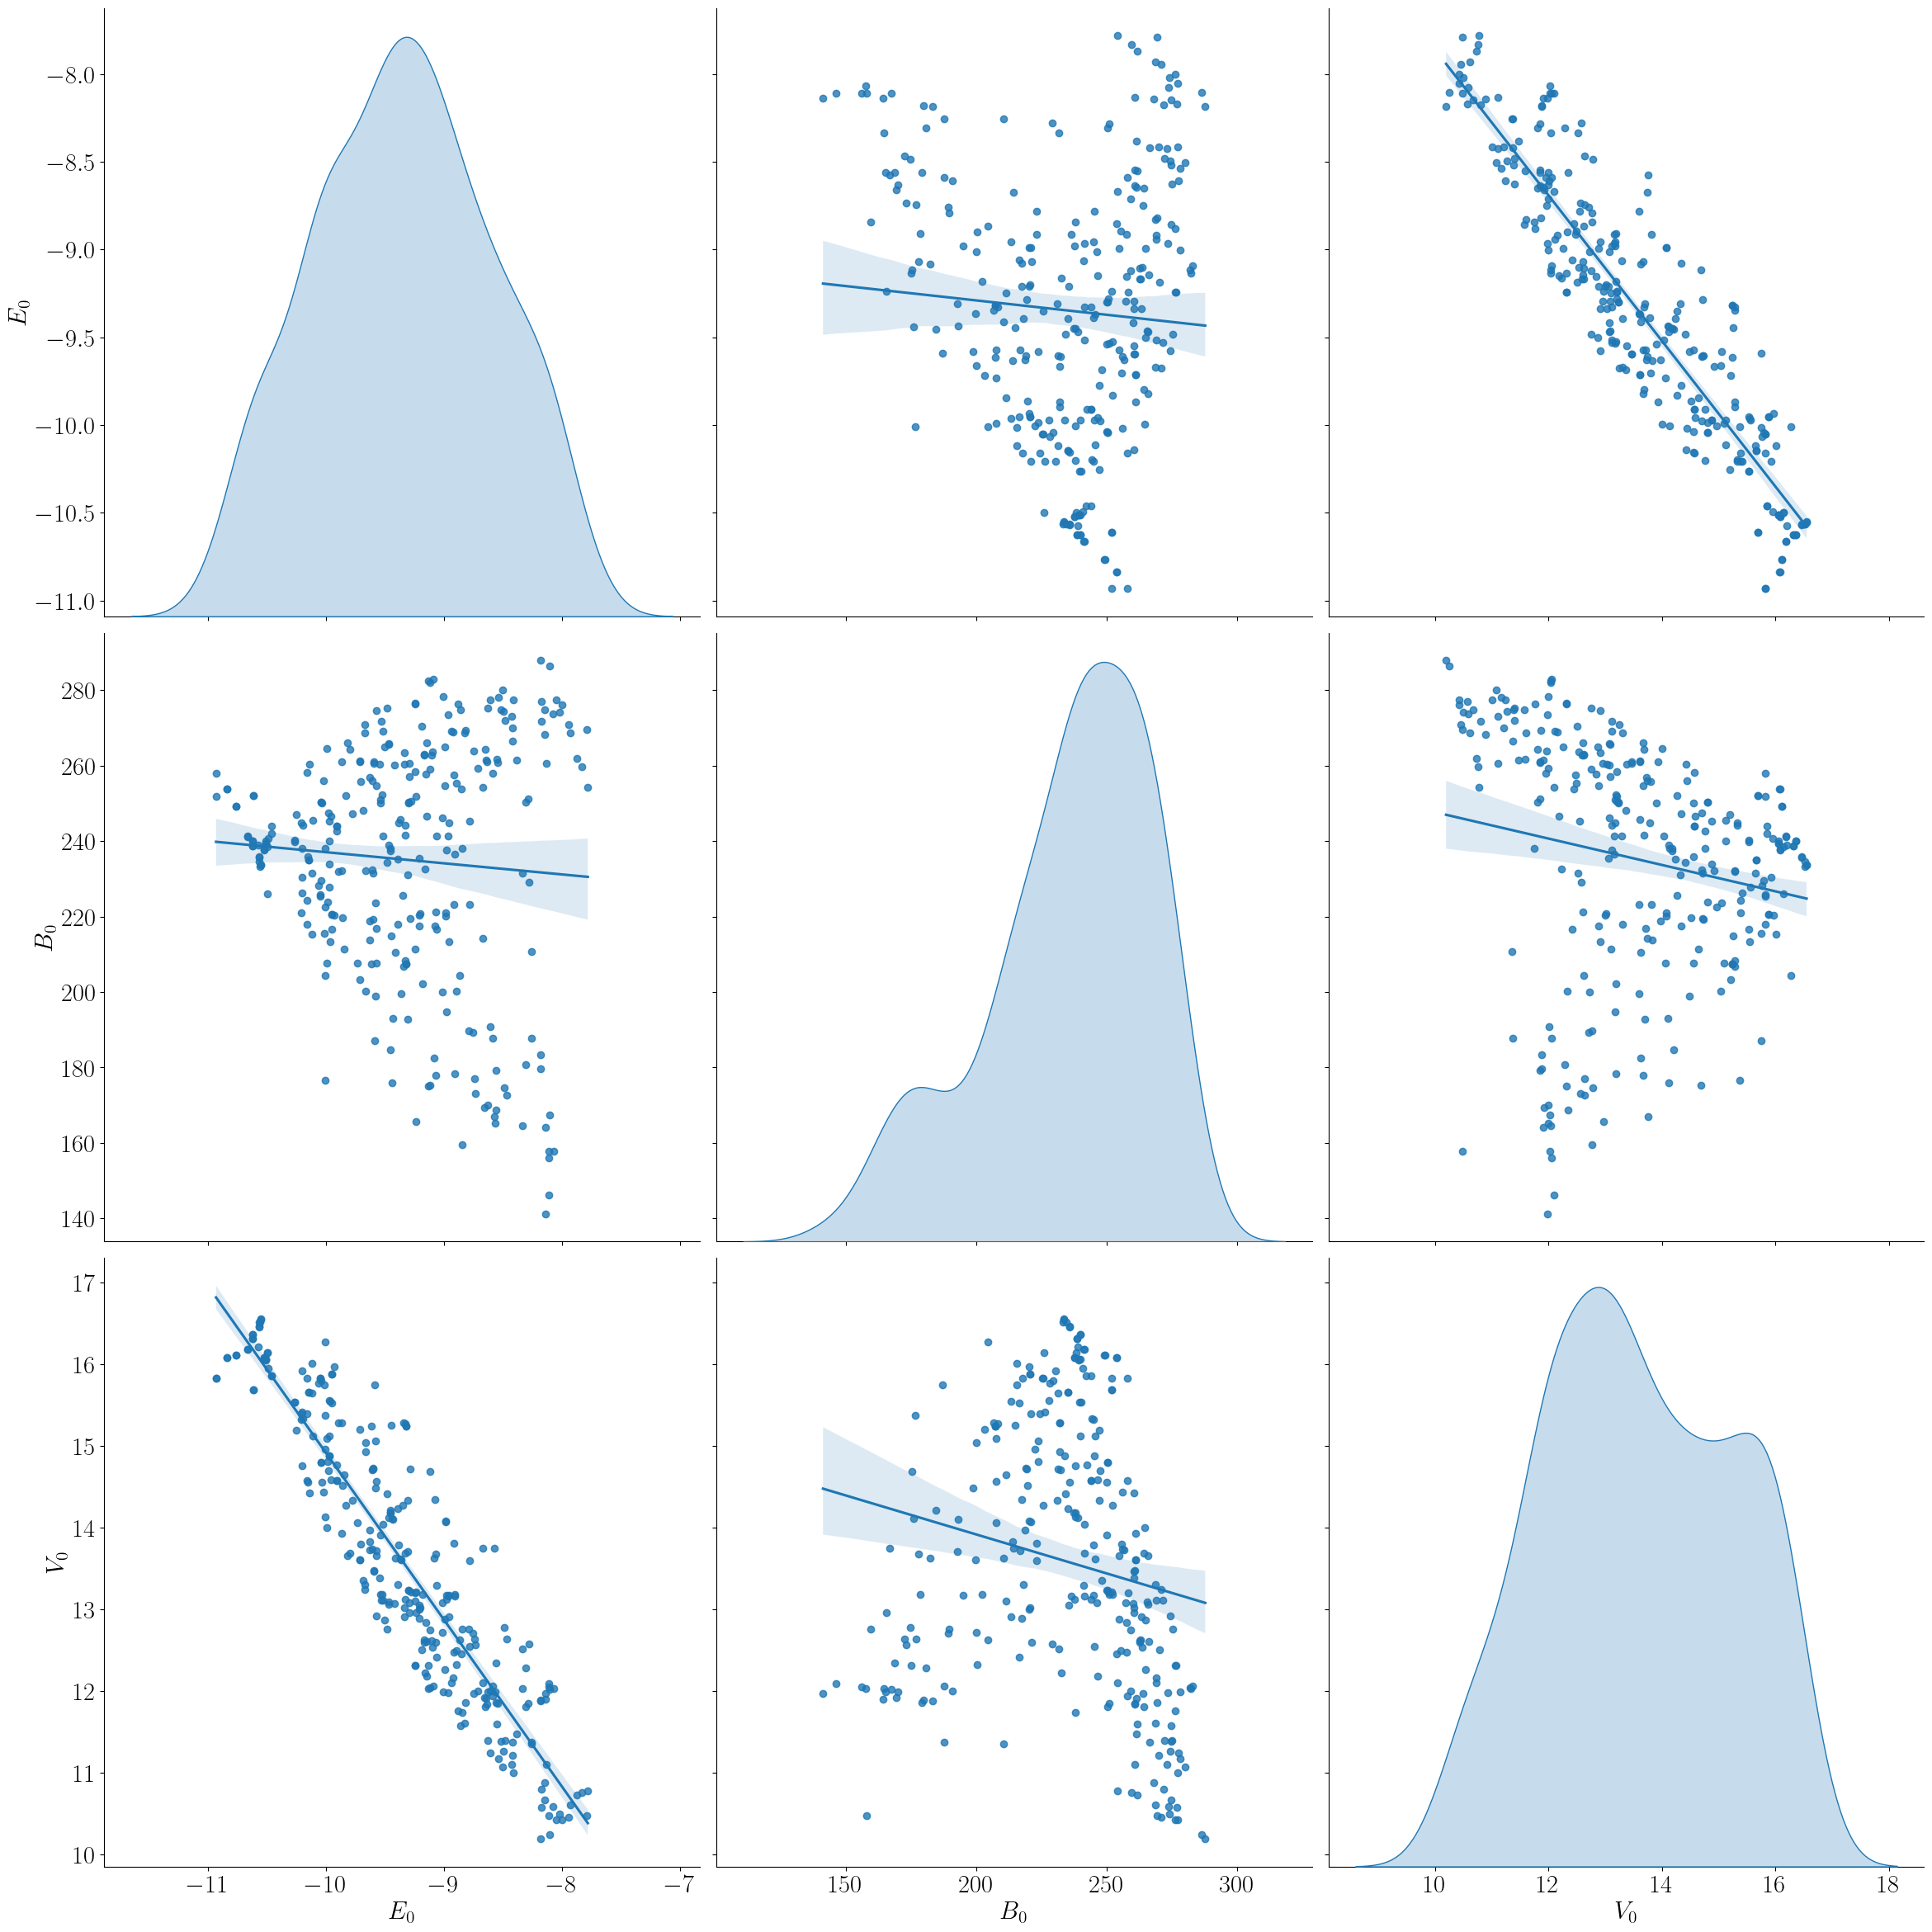

In [21]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# Magnetic vs Non Magnetic

EFFM = BS[target_case][Features.Mag == 'FM']

EFNMfcc = BS[target_case][Features.Mag == 'NM']

EFNMhcp = BS[target_case][Features.Mag == 'NM']

EFFM.index = EFFM.index.str.replace('.FM', '')

EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

EFNMhcp.index = EFNMhcp.index.str.replace('.NM', '')

DE_mag  = EFNMhcp - EFFM 

DE_mag[ abs(DE_mag > 0.1)]

DE_mag[DE_mag < 0 ]

ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmfcc'], color = 'purple', label = "NM fcc ground state")
ax = sns.histplot(BS[BS.index.str.contains('NM$')]['EF_nmhcp'], color='orange', label ='NM hcp ground state')
ax.legend()

x = [-0.1, 0.8] 
y = [-0.1, 0.8]
ax  = sns.scatterplot(EFFM, EFNMhcp, label=target_case)
ax  = sns.scatterplot(EFFM, EFNMfcc, label=target_case, ax=ax, color='purple', size = 20)
ax.plot(x,y, '--k')
ax.set_xlabel(r'$\Delta E _f $ FM  eV/atom')
ax.set_ylabel(r'$\Delta E _f $ NM  eV/atom ')
big_difference = DE_mag[DE_mag.abs()>0.18].index#.index[0]
for bigdifindex in big_difference:
    xy = (EFFM[bigdifindex], EFNMhcp[bigdifindex])
    xytext = (EFFM[bigdifindex],  EFNMhcp[bigdifindex]*1.1)
    ax.annotate(bigdifindex, xy , xytext = xytext, arrowprops={'width': 5, })

BIGDIF_FM = BS.filter(regex='E0|atom_').loc[big_difference+'.FM']

BIGDIF_NM = BS.filter(regex='E0|atom_').loc[big_difference+'.NM']

pd.concat([BIGDIF_FM, BIGDIF_NM], axis = 0)

Features.get_ground_states_energies()

EREF_FM = BS[BS.index.str.contains('FM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0']].sort_values(by='E0').iloc[0]

EREF_FM

BIGDIF_FM['E0'] - EREF_FM['E0']

EREF_NM = BS[BS.index.str.contains('NM$', regex=True) & (BS['nelem'] == 1) & (BS['atom_A'] == 'Fe_pv') ][['E0', 'num_atom_A', 'num_atoms']].sort_values(by='E0').iloc[0]

EREF_NM

BIGDIF_NM['E0'] - EREF_NM['E0']

BS.columns

# NM convex hulls (binaries only)

from Tools.DatasetTools.Tools import Plotting
P = Plotting()

from importlib.machinery import SourceFileLoader
P = SourceFileLoader('Plotting', 'Tools/DatasetTools/Tools.py').load_module().Plotting()

verts = {}
chulls = {}
phasepoints = {}

PhasesBS = {mag: {phase: BS[(BS.Phase == phase) & BS.index.str.contains(mag)] for phase in BS.Phase.unique()} for mag in ['FM', 'NM', '']}

remove = []
for mag, phasesbs in PhasesBS.items():
    for phase, bs in phasesbs.items():
        if len(bs) < 3:
            remove.append((mag, phase))

[PhasesBS[remove_mag].pop(remove_phase) for (remove_mag, remove_phase) in remove]

for mag, PhaseBS in  PhasesBS.items():
    print(mag, [(phase, len(BS))  for phase, BS in PhaseBS.items()] )
    points = P.get_x_ef_points(PhaseBS, components, property=target_case)
    chulls = P.get_convex_hulls(PhaseBS, components, return_points = False, getproperty = target_case)
    pallette = sns.color_palette("Set2", n_colors=len(PhaseBS)+1)
    #pallette.pop(-2)
    colors = {phase: color for phase, color in zip(PhaseBS.keys(), pallette)}
    fig, ax = plt.subplots()
    labels=[]
    handles = []
    for phase, chull in chulls.items():
        for visible_facet in chull.simplices[chull.good]:
            ax.plot(points[phase].iloc[:,0] , points[phase].iloc[:,1], 'o', color = colors[phase])
            l = ax.plot(chull.points[visible_facet,0], chull.points[visible_facet,1], color=colors[phase])
        handles.append(l[0])
        labels.append(phase)
    leg = ax.legend(handles, labels, bbox_to_anchor=(1.01,1), title=mag)
    setlw = [ha.set_linewidth(5) for ha in leg.get_lines() ]
    ax.set_ylabel(r'$\Delta E _f$ (eV/atom)')
    ax.set_xlabel(rf'$x_{{{components[0]}}}$')
    fig.tight_layout()
    fig.savefig(os.path.join(dataset, 'graphs',f'{dataset}_ConvxHulls_{target_case}_{mag}.eps' ))

In [22]:
BS.shape

(292, 21)